# Variational AutoEncoder (VAE) — à partir de l'AutoEncoder simple

Le VAE reprend la même structure **Encodeur → espace latent → Décodeur**, mais l'encodeur ne produit plus directement un point latent `z`.

Il produit deux vecteurs :

- `z_mean = μ`
- `z_log_var = log(σ²)`

Puis on applique le **reparameterization trick** :

\[
z = \mu + e^{0.5 \times \log(\sigma^2)} \times \epsilon,
\qquad \epsilon \sim \mathcal{N}(0,1)
\]

La loss devient :

\[
Loss = ReconstructionLoss + kl\_weight \times KL\_Divergence
\]

La KL divergence pousse l'espace latent à se rapprocher d'une loi normale standard `N(0,1)`.  
Cela permet ensuite de générer de nouvelles images en échantillonnant directement `z ~ N(0,1)` puis en utilisant le décodeur.


In [1]:
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


@dataclass
class VAEConfig:
    # "dense" ou "conv"
    architecture: str = "dense"
    latent_dim: int = 2
    hidden_dims: Tuple[int, ...] = (128, 32)

    # Activations
    hidden_activation: str = "relu"
    output_activation: str = "sigmoid"
    leaky_relu_slope: float = 0.2

    # Architecture convolutionnelle
    conv_filters: Tuple[int, ...] = (32, 64)
    conv_strides: Tuple[int, ...] = (2, 2)
    kernel_size: int = 3

    # Initialisation
    kernel_initializer: str = "glorot_uniform"

    # Apprentissage
    learning_rate: float = 1e-3
    batch_size: int = 256
    epochs: int = 200
    optimizer_name: str = "adam"
    loss_name: str = "mse"

    # Poids de la KL divergence dans la loss totale
    kl_weight: float = 1e-3

    # Préparation des données
    normalization: str = "zero_one"

    # Reproductibilité / affichage
    seed: int = 42
    n_examples: int = 10
    n_generated_images: int = 16
    latent_grid_size: int = 20
    latent_visualization_range: float = 3.0

    # Sorties
    output_dir: str = "outputs_vae_mnist"


class VariationalAutoencoder:
    IMAGE_HEIGHT = 28
    IMAGE_WIDTH = 28
    IMAGE_CHANNELS = 1
    INPUT_DIM = IMAGE_HEIGHT * IMAGE_WIDTH

    def __init__(self, config: VAEConfig):
        self.config = config
        self._validate_config()

        np.random.seed(config.seed)
        tf.random.set_seed(config.seed)

        self.output_dir = Path(config.output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

        self.encoder, self.decoder = self._build_models()
        self.optimizer = self._build_optimizer()
        self.loss_fn = tf.keras.losses.get(config.loss_name)

        self.history = {
            "total_loss": [],
            "reconstruction_loss": [],
            "kl_loss": [],
        }

    def _validate_config(self):
        cfg = self.config

        if cfg.architecture not in {"dense", "conv"}:
            raise ValueError("architecture doit être 'dense' ou 'conv'.")

        if cfg.latent_dim < 1:
            raise ValueError("latent_dim doit être >= 1.")

        if cfg.architecture == "dense" and not cfg.hidden_dims:
            raise ValueError("hidden_dims ne peut pas être vide.")

        if cfg.architecture == "conv":
            if len(cfg.conv_filters) != len(cfg.conv_strides):
                raise ValueError(
                    "conv_filters et conv_strides doivent avoir la même longueur."
                )

            total_stride = int(np.prod(cfg.conv_strides))

            if self.IMAGE_HEIGHT % total_stride != 0:
                raise ValueError(
                    "Le produit de conv_strides doit diviser exactement 28."
                )

    def _apply_activation(
        self,
        x,
        activation_name: Optional[str],
        layer_name: str,
    ):
        if activation_name in {None, "linear"}:
            return x

        if activation_name == "leaky_relu":
            return tf.keras.layers.LeakyReLU(
                negative_slope=self.config.leaky_relu_slope,
                name=layer_name,
            )(x)

        return tf.keras.layers.Activation(
            activation_name,
            name=layer_name,
        )(x)

    def _build_models(self):
        if self.config.architecture == "dense":
            return self._build_dense_models()

        return self._build_conv_models()

    def _build_dense_models(self):
        cfg = self.config

        # ---------------- ENCODEUR ----------------
        encoder_input = tf.keras.Input(
            shape=(self.INPUT_DIM,),
            name="image_flat",
        )

        x = encoder_input

        for index, units in enumerate(cfg.hidden_dims):
            x = tf.keras.layers.Dense(
                units,
                activation=None,
                kernel_initializer=cfg.kernel_initializer,
                name=f"encoder_dense_{index + 1}",
            )(x)

            x = self._apply_activation(
                x,
                cfg.hidden_activation,
                f"encoder_activation_{index + 1}",
            )

        # Le VAE prédit les paramètres de la distribution latente.
        z_mean = tf.keras.layers.Dense(
            cfg.latent_dim,
            name="z_mean",
        )(x)

        z_log_var = tf.keras.layers.Dense(
            cfg.latent_dim,
            name="z_log_var",
        )(x)

        encoder = tf.keras.Model(
            encoder_input,
            [z_mean, z_log_var],
            name="vae_dense_encoder",
        )

        # ---------------- DÉCODEUR ----------------
        decoder_input = tf.keras.Input(
            shape=(cfg.latent_dim,),
            name="latent_vector",
        )

        x = decoder_input

        for index, units in enumerate(reversed(cfg.hidden_dims)):
            x = tf.keras.layers.Dense(
                units,
                activation=None,
                kernel_initializer=cfg.kernel_initializer,
                name=f"decoder_dense_{index + 1}",
            )(x)

            x = self._apply_activation(
                x,
                cfg.hidden_activation,
                f"decoder_activation_{index + 1}",
            )

        x = tf.keras.layers.Dense(
            self.INPUT_DIM,
            activation=None,
            kernel_initializer=cfg.kernel_initializer,
            name="reconstruction_linear",
        )(x)

        decoder_output = self._apply_activation(
            x,
            cfg.output_activation,
            "reconstruction_activation",
        )

        decoder = tf.keras.Model(
            decoder_input,
            decoder_output,
            name="vae_dense_decoder",
        )

        return encoder, decoder

    def _build_conv_models(self):
        cfg = self.config

        # ---------------- ENCODEUR ----------------
        encoder_input = tf.keras.Input(
            shape=(
                self.IMAGE_HEIGHT,
                self.IMAGE_WIDTH,
                self.IMAGE_CHANNELS,
            ),
            name="image",
        )

        x = encoder_input

        for index, (filters, stride) in enumerate(
            zip(cfg.conv_filters, cfg.conv_strides)
        ):
            x = tf.keras.layers.Conv2D(
                filters=filters,
                kernel_size=cfg.kernel_size,
                strides=stride,
                padding="same",
                activation=None,
                kernel_initializer=cfg.kernel_initializer,
                name=f"encoder_conv_{index + 1}",
            )(x)

            x = self._apply_activation(
                x,
                cfg.hidden_activation,
                f"encoder_conv_activation_{index + 1}",
            )

        shape_before_flatten = tuple(
            int(dimension)
            for dimension in x.shape[1:]
        )

        x = tf.keras.layers.Flatten(
            name="encoder_flatten"
        )(x)

        z_mean = tf.keras.layers.Dense(
            cfg.latent_dim,
            name="z_mean",
        )(x)

        z_log_var = tf.keras.layers.Dense(
            cfg.latent_dim,
            name="z_log_var",
        )(x)

        encoder = tf.keras.Model(
            encoder_input,
            [z_mean, z_log_var],
            name="vae_conv_encoder",
        )

        # ---------------- DÉCODEUR ----------------
        decoder_input = tf.keras.Input(
            shape=(cfg.latent_dim,),
            name="latent_vector",
        )

        x = tf.keras.layers.Dense(
            int(np.prod(shape_before_flatten)),
            activation=None,
            kernel_initializer=cfg.kernel_initializer,
            name="decoder_dense_projection",
        )(decoder_input)

        x = self._apply_activation(
            x,
            cfg.hidden_activation,
            "decoder_projection_activation",
        )

        x = tf.keras.layers.Reshape(
            shape_before_flatten,
            name="decoder_reshape",
        )(x)

        for reverse_index in range(
            len(cfg.conv_filters) - 1,
            0,
            -1,
        ):
            x = tf.keras.layers.Conv2DTranspose(
                filters=cfg.conv_filters[reverse_index - 1],
                kernel_size=cfg.kernel_size,
                strides=cfg.conv_strides[reverse_index],
                padding="same",
                activation=None,
                kernel_initializer=cfg.kernel_initializer,
                name=f"decoder_deconv_{reverse_index}",
            )(x)

            x = self._apply_activation(
                x,
                cfg.hidden_activation,
                f"decoder_deconv_activation_{reverse_index}",
            )

        x = tf.keras.layers.Conv2DTranspose(
            filters=self.IMAGE_CHANNELS,
            kernel_size=cfg.kernel_size,
            strides=cfg.conv_strides[0],
            padding="same",
            activation=None,
            kernel_initializer=cfg.kernel_initializer,
            name="reconstruction_conv",
        )(x)

        decoder_output = self._apply_activation(
            x,
            cfg.output_activation,
            "reconstruction_activation",
        )

        decoder = tf.keras.Model(
            decoder_input,
            decoder_output,
            name="vae_conv_decoder",
        )

        return encoder, decoder

    def _build_optimizer(self):
        name = self.config.optimizer_name.lower()
        learning_rate = self.config.learning_rate

        if name == "adam":
            return tf.keras.optimizers.Adam(
                learning_rate=learning_rate
            )

        if name == "sgd":
            return tf.keras.optimizers.SGD(
                learning_rate=learning_rate
            )

        if name == "rmsprop":
            return tf.keras.optimizers.RMSprop(
                learning_rate=learning_rate
            )

        raise ValueError(
            "optimizer_name doit être 'adam', 'sgd' ou 'rmsprop'."
        )

    def load_mnist(self):
        (x_train, y_train), (x_test, y_test) = (
            tf.keras.datasets.mnist.load_data()
        )

        x_train = x_train.astype(np.float32)
        x_test = x_test.astype(np.float32)

        if self.config.normalization == "zero_one":
            x_train = x_train / 255.0
            x_test = x_test / 255.0
        else:
            x_train = (x_train / 127.5) - 1.0
            x_test = (x_test / 127.5) - 1.0

        if self.config.architecture == "dense":
            x_train = x_train.reshape(-1, self.INPUT_DIM)
            x_test = x_test.reshape(-1, self.INPUT_DIM)
        else:
            x_train = np.expand_dims(x_train, axis=-1)
            x_test = np.expand_dims(x_test, axis=-1)

        print("\n================ DONNÉES MNIST ================")
        print("Architecture :", self.config.architecture)
        print("x_train      :", x_train.shape)
        print("x_test       :", x_test.shape)
        print("Pixel min/max:", x_train.min(), "/", x_train.max())

        return x_train, y_train, x_test, y_test

    def _make_dataset(self, x_train):
        return (
            tf.data.Dataset
            .from_tensor_slices(x_train)
            .shuffle(
                buffer_size=len(x_train),
                seed=self.config.seed,
                reshuffle_each_iteration=True,
            )
            .batch(self.config.batch_size)
            .prefetch(tf.data.AUTOTUNE)
        )

    # Reparameterization Trick :
    # z = mu + exp(0.5 * log(sigma²)) * epsilon
    # avec epsilon ~ N(0,1)
    def sample_latent(self, z_mean, z_log_var):
        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        return (
            z_mean
            + tf.exp(0.5 * z_log_var)
            * epsilon
        )

    def forward(self, x, training=False):
        z_mean, z_log_var = self.encoder(
            x,
            training=training,
        )

        z = self.sample_latent(
            z_mean,
            z_log_var,
        )

        reconstruction = self.decoder(
            z,
            training=training,
        )

        return (
            z_mean,
            z_log_var,
            z,
            reconstruction,
        )

    def _compute_losses(
        self,
        x_true,
        x_reconstructed,
        z_mean,
        z_log_var,
    ):
        # 1. Loss de reconstruction : même idée que l'AutoEncoder simple.
        reconstruction_loss = self.loss_fn(
            x_true,
            x_reconstructed,
        )
        reconstruction_loss = tf.reduce_mean(
            reconstruction_loss
        )

        # 2. KL divergence vers N(0,1).
        kl_loss = -0.5 * tf.reduce_sum(
            1
            + z_log_var
            - tf.square(z_mean)
            - tf.exp(z_log_var),
            axis=1,
        )
        kl_loss = tf.reduce_mean(
            kl_loss
        )

        # 3. Loss totale du cours :
        # reconstruction + coefficient_KL * KL
        total_loss = (
            reconstruction_loss
            + self.config.kl_weight
            * kl_loss
        )

        return (
            total_loss,
            reconstruction_loss,
            kl_loss,
        )

    @tf.function
    def train_step(self, x_batch):
        with tf.GradientTape() as tape:
            (
                z_mean,
                z_log_var,
                _,
                reconstruction,
            ) = self.forward(
                x_batch,
                training=True,
            )

            (
                total_loss,
                reconstruction_loss,
                kl_loss,
            ) = self._compute_losses(
                x_batch,
                reconstruction,
                z_mean,
                z_log_var,
            )

        variables = (
            self.encoder.trainable_variables
            + self.decoder.trainable_variables
        )

        gradients = tape.gradient(
            total_loss,
            variables,
        )

        self.optimizer.apply_gradients(
            zip(gradients, variables)
        )

        return (
            total_loss,
            reconstruction_loss,
            kl_loss,
        )

    def fit(self, x_train):
        train_dataset = self._make_dataset(
            x_train
        )

        self.history = {
            "total_loss": [],
            "reconstruction_loss": [],
            "kl_loss": [],
        }

        print("\n================ ENTRAÎNEMENT VAE ================")
        self.print_config()

        for epoch in range(
            1,
            self.config.epochs + 1,
        ):
            total_metric = tf.keras.metrics.Mean()
            reconstruction_metric = tf.keras.metrics.Mean()
            kl_metric = tf.keras.metrics.Mean()

            for x_batch in train_dataset:
                (
                    total_loss,
                    reconstruction_loss,
                    kl_loss,
                ) = self.train_step(
                    x_batch
                )

                total_metric.update_state(
                    total_loss
                )
                reconstruction_metric.update_state(
                    reconstruction_loss
                )
                kl_metric.update_state(
                    kl_loss
                )

            epoch_total = float(
                total_metric.result().numpy()
            )
            epoch_reconstruction = float(
                reconstruction_metric.result().numpy()
            )
            epoch_kl = float(
                kl_metric.result().numpy()
            )

            self.history["total_loss"].append(
                epoch_total
            )
            self.history["reconstruction_loss"].append(
                epoch_reconstruction
            )
            self.history["kl_loss"].append(
                epoch_kl
            )

            print(
                f"Epoch {epoch:03d}/{self.config.epochs} "
                f"- total: {epoch_total:.6f} "
                f"- reconstruction: {epoch_reconstruction:.6f} "
                f"- KL: {epoch_kl:.6f}"
            )

        return self.history

    def evaluate(self, x_test):
        total_metric = tf.keras.metrics.Mean()
        reconstruction_metric = tf.keras.metrics.Mean()
        kl_metric = tf.keras.metrics.Mean()

        dataset = (
            tf.data.Dataset
            .from_tensor_slices(x_test)
            .batch(self.config.batch_size)
        )

        for x_batch in dataset:
            (
                z_mean,
                z_log_var,
                _,
                reconstruction,
            ) = self.forward(
                x_batch,
                training=False,
            )

            (
                total_loss,
                reconstruction_loss,
                kl_loss,
            ) = self._compute_losses(
                x_batch,
                reconstruction,
                z_mean,
                z_log_var,
            )

            total_metric.update_state(
                total_loss
            )
            reconstruction_metric.update_state(
                reconstruction_loss
            )
            kl_metric.update_state(
                kl_loss
            )

        values = {
            "total_loss": float(
                total_metric.result().numpy()
            ),
            "reconstruction_loss": float(
                reconstruction_metric.result().numpy()
            ),
            "kl_loss": float(
                kl_metric.result().numpy()
            ),
        }

        print("\n================ ÉVALUATION VAE ================")
        print(values)

        return values

    def encode(self, x):
        z_mean, z_log_var = self.encoder.predict(
            x,
            batch_size=self.config.batch_size,
            verbose=0,
        )

        epsilon = np.random.default_rng(
            self.config.seed
        ).normal(
            size=z_mean.shape
        ).astype(np.float32)

        z = (
            z_mean
            + np.exp(0.5 * z_log_var)
            * epsilon
        )

        return (
            z_mean,
            z_log_var,
            z,
        )

    def decode(self, z):
        return self.decoder.predict(
            z,
            batch_size=self.config.batch_size,
            verbose=0,
        )

    def reconstruct(self, x):
        (
            z_mean,
            z_log_var,
            z,
        ) = self.encode(x)

        reconstruction = self.decode(
            z
        )

        return (
            z_mean,
            z_log_var,
            z,
            reconstruction,
        )

    def print_config(self):
        cfg = self.config

        print("\n--- CONFIGURATION VAE ---")
        print("architecture       :", cfg.architecture)
        print("latent_dim         :", cfg.latent_dim)
        print("hidden_dims        :", cfg.hidden_dims)
        print("hidden_activation  :", cfg.hidden_activation)
        print("output_activation  :", cfg.output_activation)
        print("optimizer          :", cfg.optimizer_name)
        print("learning_rate      :", cfg.learning_rate)
        print("loss reconstruction:", cfg.loss_name)
        print("kl_weight          :", cfg.kl_weight)
        print("batch_size         :", cfg.batch_size)
        print("epochs             :", cfg.epochs)

    def show_summaries(self):
        print("\n================ ENCODEUR VAE ================")
        self.encoder.summary()

        print("\n================ DÉCODEUR VAE ================")
        self.decoder.summary()

    def plot_train_reconstructions(
        self,
        x_train,
        n_examples: Optional[int] = None,
    ):
        if n_examples is None:
            n_examples = self.config.n_examples

        x_examples = x_train[:n_examples]

        (
            _,
            _,
            _,
            reconstructed,
        ) = self.reconstruct(
            x_examples
        )

        fig, axes = plt.subplots(
            2,
            n_examples,
            figsize=(1.8 * n_examples, 4.5),
        )

        if n_examples == 1:
            axes = np.array(
                axes
            ).reshape(2, 1)

        for index in range(n_examples):
            axes[0, index].imshow(
                self._to_display_image(
                    x_examples[index]
                ),
                cmap="gray",
            )

            axes[1, index].imshow(
                self._to_display_image(
                    reconstructed[index]
                ),
                cmap="gray",
            )

            axes[0, index].axis("off")
            axes[1, index].axis("off")

        axes[0, 0].set_ylabel(
            "Original"
        )
        axes[1, 0].set_ylabel(
            "Reconstruit"
        )

        fig.suptitle(
            "VAE - Reconstructions sur le train"
        )

        fig.tight_layout()
        plt.show()

        return reconstructed, fig

    def plot_history(self):
        fig = plt.figure(
            figsize=(9, 5)
        )

        epochs = range(
            1,
            len(self.history["total_loss"]) + 1,
        )

        plt.plot(
            epochs,
            self.history["total_loss"],
            label="Loss totale",
        )

        plt.plot(
            epochs,
            self.history["reconstruction_loss"],
            label="Reconstruction",
        )

        plt.plot(
            epochs,
            self.history["kl_loss"],
            label="KL divergence",
        )

        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(
            "VAE MNIST - évolution des losses"
        )
        plt.legend()
        plt.grid(
            True,
            alpha=0.3,
        )
        plt.tight_layout()
        plt.show()

        return fig

    def inspect_latent_and_reconstructions(
        self,
        x_test,
        y_test,
        n_examples: Optional[int] = None,
    ):
        if n_examples is None:
            n_examples = self.config.n_examples

        x_examples = x_test[:n_examples]
        y_examples = y_test[:n_examples]

        (
            z_mean,
            z_log_var,
            z,
            reconstructed,
        ) = self.reconstruct(
            x_examples
        )

        print(
            "\n========== DISTRIBUTIONS LATENTES =========="
        )

        for index in range(n_examples):
            print(
                f"Image {index:02d} | y={y_examples[index]} "
                f"| mu={np.round(z_mean[index], 3)} "
                f"| log_var={np.round(z_log_var[index], 3)} "
                f"| z={np.round(z[index], 3)}"
            )

        fig, axes = plt.subplots(
            2,
            n_examples,
            figsize=(1.8 * n_examples, 4.8),
        )

        if n_examples == 1:
            axes = np.array(
                axes
            ).reshape(2, 1)

        for index in range(n_examples):
            axes[0, index].imshow(
                self._to_display_image(
                    x_examples[index]
                ),
                cmap="gray",
            )

            axes[1, index].imshow(
                self._to_display_image(
                    reconstructed[index]
                ),
                cmap="gray",
            )

            axes[0, index].set_title(
                f"y={y_examples[index]}\n"
                f"z={np.round(z[index], 2)}",
                fontsize=8,
            )

            axes[0, index].axis("off")
            axes[1, index].axis("off")

        axes[0, 0].set_ylabel(
            "Originale"
        )
        axes[1, 0].set_ylabel(
            "Reconstruite"
        )

        fig.suptitle(
            "VAE - Distribution latente et reconstruction"
        )

        fig.tight_layout()
        plt.show()

        return (
            z_mean,
            z_log_var,
            z,
            reconstructed,
            fig,
        )

    def visualize_latent_space(
        self,
        grid_size: Optional[int] = None,
    ):
        if self.config.latent_dim != 2:
            print(
                "Visualisation directe disponible uniquement "
                "avec latent_dim=2."
            )
            return None

        if grid_size is None:
            grid_size = self.config.latent_grid_size

        limit = (
            self.config.latent_visualization_range
        )

        z1_values = np.linspace(
            -limit,
            limit,
            grid_size,
            dtype=np.float32,
        )

        z2_values = np.linspace(
            limit,
            -limit,
            grid_size,
            dtype=np.float32,
        )

        latent_points = np.array(
            [
                [z1, z2]
                for z2 in z2_values
                for z1 in z1_values
            ],
            dtype=np.float32,
        )

        decoded = self.decode(
            latent_points
        )

        canvas = np.zeros(
            (
                self.IMAGE_HEIGHT * grid_size,
                self.IMAGE_WIDTH * grid_size,
            ),
            dtype=np.float32,
        )

        index = 0

        for row in range(grid_size):
            for column in range(grid_size):
                image = self._to_display_image(
                    decoded[index]
                )

                row_start = (
                    row
                    * self.IMAGE_HEIGHT
                )
                column_start = (
                    column
                    * self.IMAGE_WIDTH
                )

                canvas[
                    row_start:
                    row_start + self.IMAGE_HEIGHT,
                    column_start:
                    column_start + self.IMAGE_WIDTH,
                ] = image

                index += 1

        fig = plt.figure(
            figsize=(12, 12)
        )

        plt.imshow(
            canvas,
            cmap="gray",
            extent=[
                -limit,
                limit,
                -limit,
                limit,
            ],
            origin="upper",
            aspect="auto",
        )

        plt.xlabel("Dimension latente z1")
        plt.ylabel("Dimension latente z2")
        plt.title(
            "VAE - Espace latent régularisé vers N(0,1)"
        )

        plt.tight_layout()
        plt.show()

        return (
            latent_points,
            decoded,
            fig,
        )

    def generate_images(
        self,
        n_images: Optional[int] = None,
    ):
        if n_images is None:
            n_images = (
                self.config.n_generated_images
            )

        rng = np.random.default_rng(
            self.config.seed
        )

        # Dans un VAE, on peut échantillonner directement N(0,1)
        # grâce à la régularisation KL.
        sampled_z = rng.normal(
            loc=0.0,
            scale=1.0,
            size=(
                n_images,
                self.config.latent_dim,
            ),
        ).astype(np.float32)

        generated = self.decode(
            sampled_z
        )

        n_cols = int(
            np.ceil(
                np.sqrt(n_images)
            )
        )

        n_rows = int(
            np.ceil(
                n_images
                / n_cols
            )
        )

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(
                2 * n_cols,
                2 * n_rows,
            ),
        )

        axes = np.array(
            axes
        ).reshape(-1)

        for index, axis in enumerate(
            axes
        ):
            axis.axis("off")

            if index < n_images:
                axis.imshow(
                    self._to_display_image(
                        generated[index]
                    ),
                    cmap="gray",
                )

                axis.set_title(
                    f"z={np.round(sampled_z[index], 2)}",
                    fontsize=7,
                )

        fig.suptitle(
            "VAE - Images générées avec z ~ N(0,1)"
        )

        fig.tight_layout()
        plt.show()

        return (
            sampled_z,
            generated,
            fig,
        )

    def _to_display_image(self, image):
        image = np.asarray(
            image
        )

        if self.config.architecture == "dense":
            image = image.reshape(
                self.IMAGE_HEIGHT,
                self.IMAGE_WIDTH,
            )
        else:
            image = np.squeeze(
                image,
                axis=-1,
            )

        if self.config.normalization == "minus_one_one":
            image = (
                image + 1.0
            ) / 2.0

        return np.clip(
            image,
            0.0,
            1.0,
        )


In [2]:
CONFIG = VAEConfig(
    architecture="dense",
    latent_dim=2,

    hidden_dims=(128, 32),

    hidden_activation="relu",
    output_activation="sigmoid",

    kernel_initializer="glorot_uniform",

    learning_rate=1e-3,
    batch_size=256,
    epochs=200,

    optimizer_name="adam",
    loss_name="mse",

    # Loss totale = reconstruction + kl_weight * KL
    kl_weight=1e-3,

    normalization="zero_one",

    n_examples=10,
    n_generated_images=16,
    latent_grid_size=20,
    latent_visualization_range=3.0,
)

vae = VariationalAutoencoder(
    CONFIG
)

vae.print_config()
vae.show_summaries()



--- CONFIGURATION VAE ---
architecture       : dense
latent_dim         : 2
hidden_dims        : (128, 32)
hidden_activation  : relu
output_activation  : sigmoid
optimizer          : adam
learning_rate      : 0.001
loss reconstruction: mse
kl_weight          : 0.001
batch_size         : 256
epochs             : 200

================ ENCODEUR VAE ================


Model: "vae_dense_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_flat          │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_1     │ (None, 128)       │    100,480 │ image_flat[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_activation… │ (None, 128)       │          0 │ encoder_dense_1[… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_2     │ (None, 32)        │      4,128 │ encoder_activati… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_activation… │ (None, 32)        │          0 │ encoder_dense_2[… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         66 │ encoder_activati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         66 │ encoder_activati… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 104,740 (409.14 KB)

 Trainable params: 104,740 (409.14 KB)

...

Model: "vae_dense_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ latent_vector (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_activation_1            │ (None, 32)             │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_activation_2            │ (None, 128)            │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction_linear (Dense)   │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction_activation       │ (None, 784)            │             0 │
│ (Activation)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,456 (411.94 KB)

 Trainable params: 105,456 (411.94 KB)

 Non-trainable params: 0 (0.00 B)


================ DONNÉES MNIST ================
Architecture : dense
x_train      : (60000, 784)
x_test       : (10000, 784)
Pixel min/max: 0.0 / 1.0

Première image - shape : (784,)


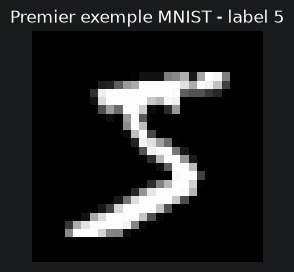

In [3]:
x_train, y_train, x_test, y_test = vae.load_mnist()

print("\nPremière image - shape :", x_train[0].shape)

fig = plt.figure(
    figsize=(3, 3)
)

plt.imshow(
    vae._to_display_image(
        x_train[0]
    ),
    cmap="gray",
)

plt.title(
    f"Premier exemple MNIST - label {y_train[0]}"
)

plt.axis("off")
plt.show()


In [4]:
history = vae.fit(
    x_train
)



================ ENTRAÎNEMENT VAE ================

--- CONFIGURATION VAE ---
architecture       : dense
latent_dim         : 2
hidden_dims        : (128, 32)
hidden_activation  : relu
output_activation  : sigmoid
optimizer          : adam
learning_rate      : 0.001
loss reconstruction: mse
kl_weight          : 0.001
batch_size         : 256
epochs             : 200
Epoch 001/200 - total: 0.078022 - reconstruction: 0.073122 - KL: 4.899747
Epoch 002/200 - total: 0.058121 - reconstruction: 0.055341 - KL: 2.780376
Epoch 003/200 - total: 0.055356 - reconstruction: 0.052141 - KL: 3.214455
Epoch 004/200 - total: 0.053849 - reconstruction: 0.050370 - KL: 3.479454
Epoch 005/200 - total: 0.052792 - reconstruction: 0.049141 - KL: 3.651296
Epoch 006/200 - total: 0.051956 - reconstruction: 0.048168 - KL: 3.788619
Epoch 007/200 - total: 0.051340 - reconstruction: 0.047417 - KL: 3.922133
Epoch 008/200 - total: 0.050720 - reconstruction: 0.046696 - KL: 4.024191
Epoch 009/200 - total: 0.050218 - reco

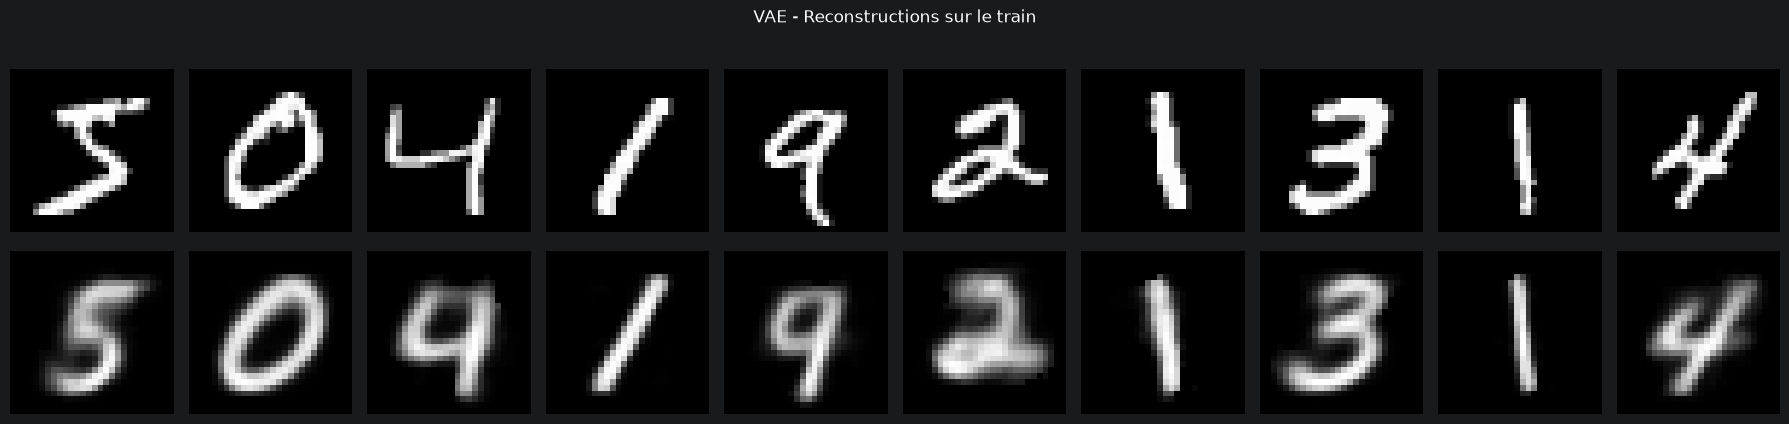

In [5]:
train_reconstructions, _ = (
    vae.plot_train_reconstructions(
        x_train
    )
)


## Évaluation et courbes de loss

Le VAE affiche maintenant trois valeurs :

- **Reconstruction loss** : qualité de reconstruction.
- **KL divergence** : distance entre les distributions latentes apprises et `N(0,1)`.
- **Total loss** : `reconstruction + kl_weight × KL`.



================ ÉVALUATION VAE ================
{'total_loss': 0.0432986244559288, 'reconstruction_loss': 0.03759158402681351, 'kl_loss': 5.707043647766113}


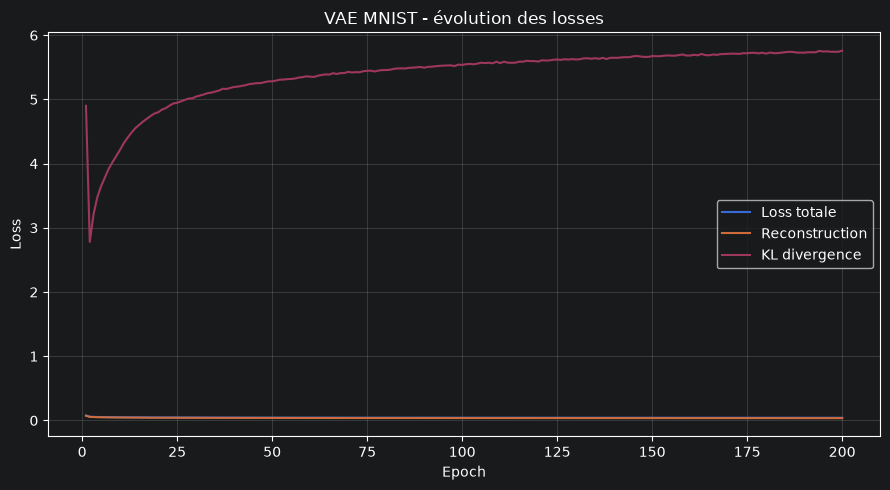

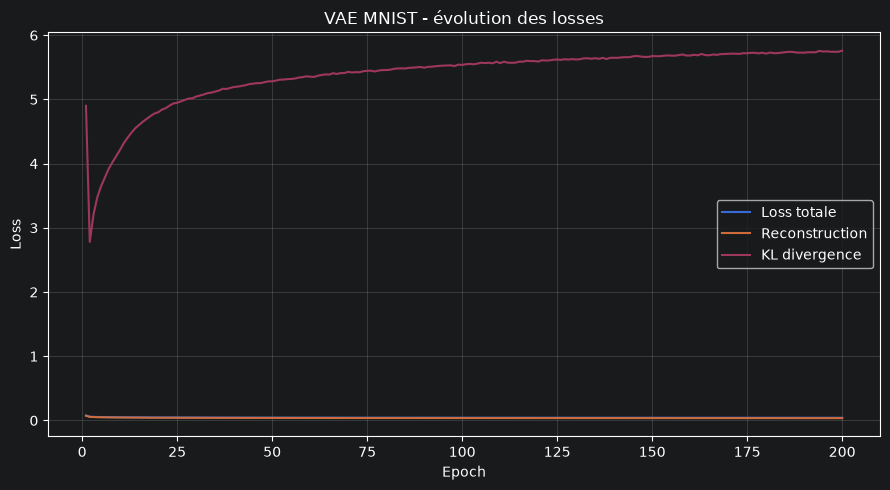

In [6]:
test_losses = vae.evaluate(
    x_test
)

vae.plot_history()



========== DISTRIBUTIONS LATENTES ==========
Image 00 | y=7 | mu=[ 2.199 -0.28 ] | log_var=[-4.12  -5.707] | z=[ 2.238 -0.34 ]
Image 01 | y=2 | mu=[-1.581 -2.42 ] | log_var=[-4.84 -3.87] | z=[-1.515 -2.285]
Image 02 | y=1 | mu=[ 0.616 -2.153] | log_var=[-5.615 -3.18 ] | z=[ 0.498 -2.419]
Image 03 | y=0 | mu=[-1.169  0.727] | log_var=[-5.589 -6.167] | z=[-1.161  0.712]
Image 04 | y=4 | mu=[0.491 1.111] | log_var=[-6.31  -4.746] | z=[0.49  1.032]
Image 05 | y=1 | mu=[ 0.512 -1.81 ] | log_var=[-5.614 -3.783] | z=[ 0.565 -1.692]
Image 06 | y=4 | mu=[0.867 0.346] | log_var=[-5.216 -5.734] | z=[0.872 0.41 ]
Image 07 | y=9 | mu=[0.902 1.122] | log_var=[-5.156 -4.713] | z=[0.938 1.041]
Image 08 | y=5 | mu=[0.331 0.782] | log_var=[-6.194 -5.097] | z=[0.348 0.707]
Image 09 | y=9 | mu=[ 1.145 -0.214] | log_var=[-5.653 -6.9  ] | z=[ 1.197 -0.216]


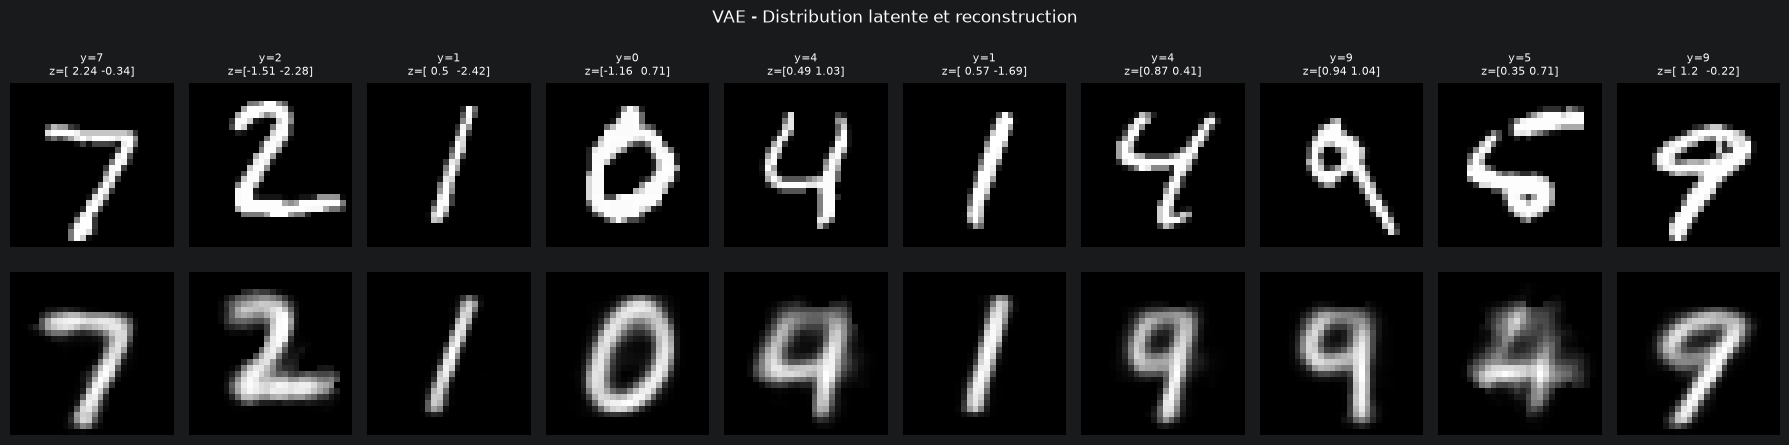

In [7]:
(
    z_mean_examples,
    z_log_var_examples,
    z_examples,
    reconstructed_examples,
    _,
) = vae.inspect_latent_and_reconstructions(
    x_test,
    y_test,
)


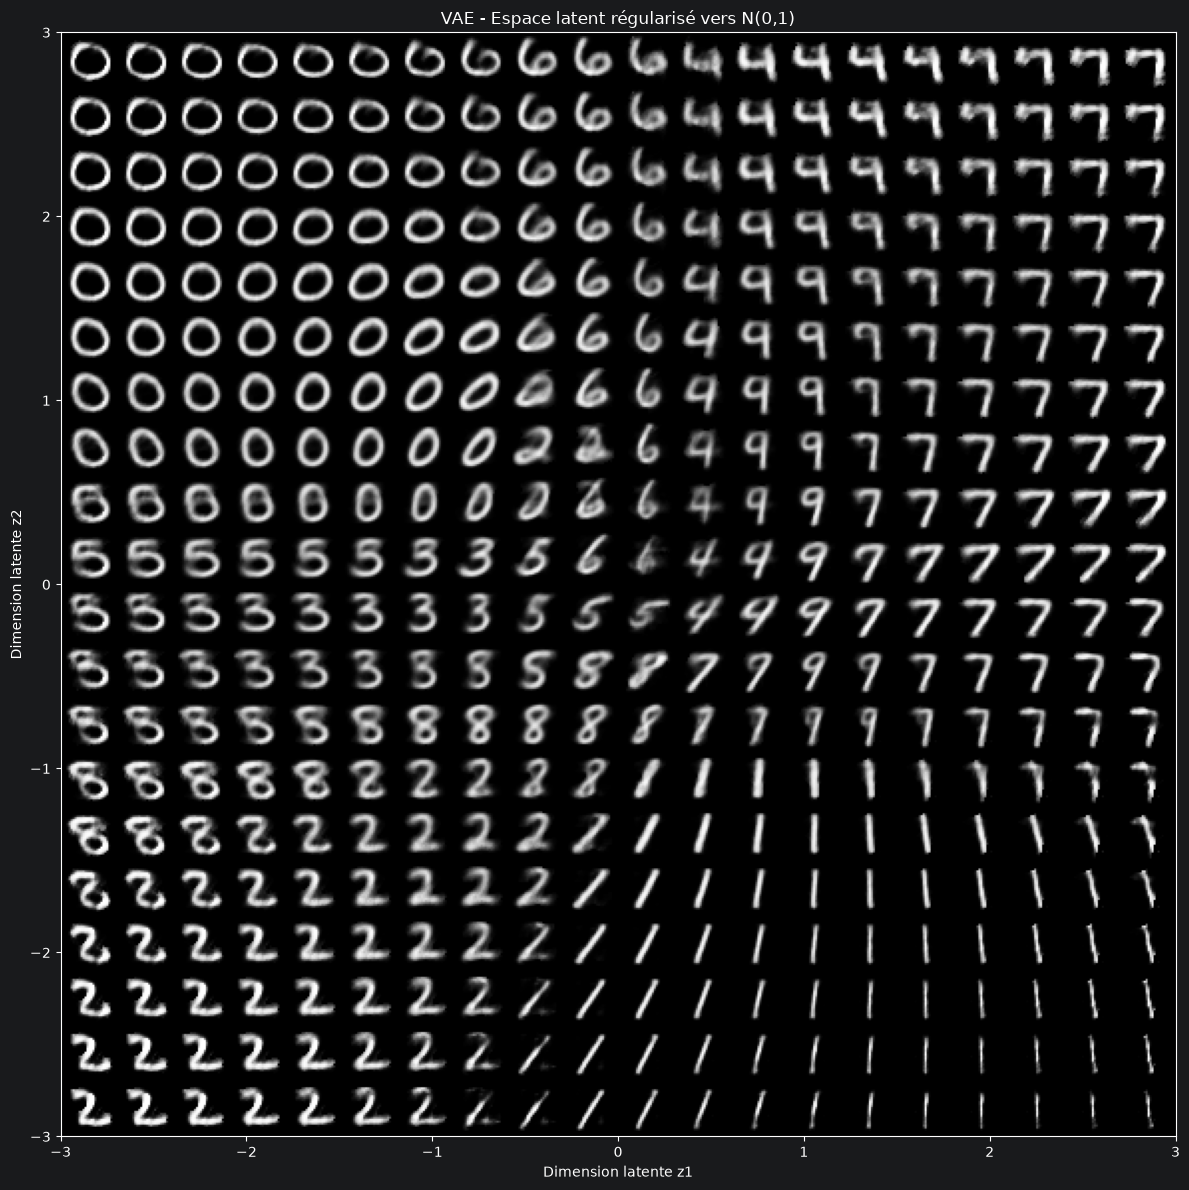

In [8]:
latent_visualization = (
    vae.visualize_latent_space()
)


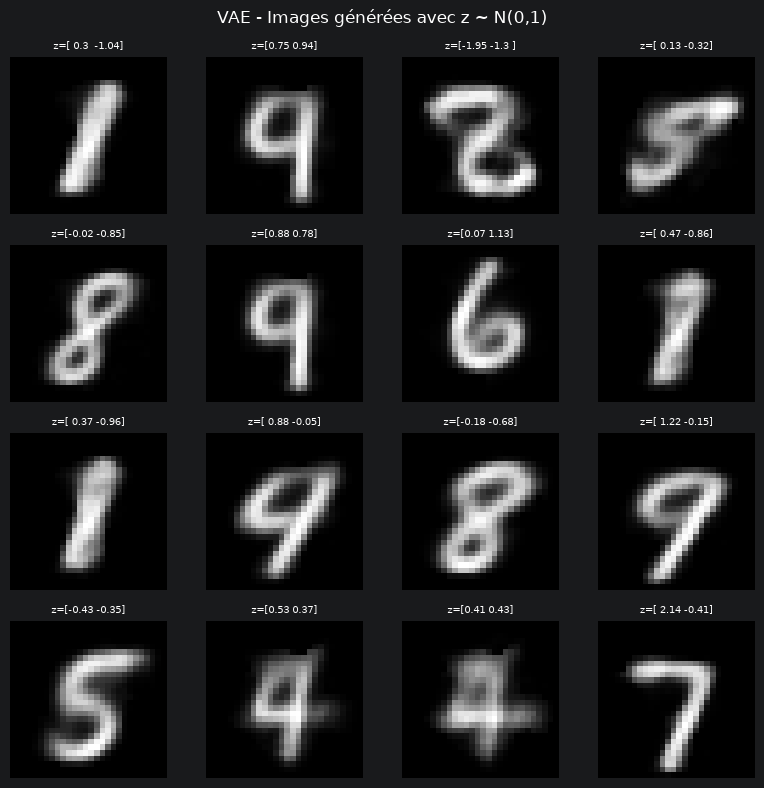

In [9]:
sampled_z, generated_images, _ = (
    vae.generate_images()
)
